In [ ]:
# If you're on Colab, run once
!pip install -q matminer pymatgen scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets import load_dataset
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Load data
df = load_dataset("matbench_perovskites")

target_col = "e_form"
structure_col = "structure"
formula_col = "formula"

df[formula_col] = df[structure_col].apply(lambda s: s.composition.reduced_formula)

print("Shape:", df.shape)
df[[formula_col, target_col]].head()

Shape: (18928, 3)


,formula,e_form
0,TeRhN3,2.16
1,HfTeO3,1.52
2,ReAsO2F,1.48
3,ReWSO2,1.24
4,HfBiO2F,0.62


In [ ]:
# Featurization
str_to_comp = StrToComposition(target_col_id="composition")
ep = ElementProperty.from_preset("magpie")

data = str_to_comp.featurize_dataframe(df.copy(), col_id=formula_col)
data = ep.featurize_dataframe(data, col_id="composition")

print("Featurized shape:", data.shape)

StrToComposition:   0%|          | 0/18928 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/18928 [00:00<?, ?it/s]

Featurized shape: (18928, 136)


In [ ]:
# Build X and y
data = data.dropna(subset=[target_col]).reset_index(drop=True)

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove(target_col)

X = data[feature_cols].values.astype(np.float32)
y = data[target_col].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (15142, 132)
X_test : (3786, 132)


In [ ]:
def report(model_name, y_true, y_pred):
    print(f"{model_name} Test MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"{model_name} Test R2 : {r2_score(y_true, y_pred):.3f}")

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--")

    plt.xlabel("DFT e_form")
    plt.ylabel("Predicted e_form")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Linear Test MAE: 0.4744
Linear Test R2 : 0.333


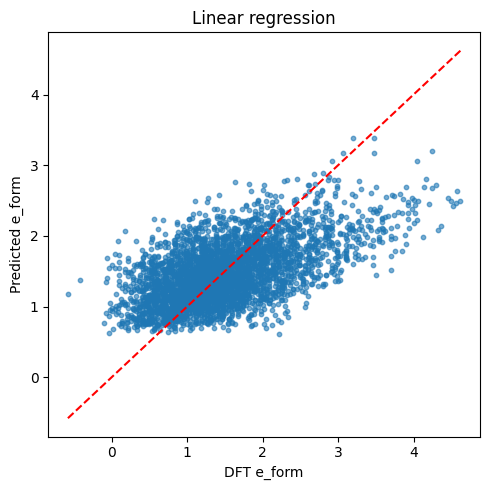

In [ ]:
# Baseline model: Linear Regression
lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred_lin = lin.predict(X_test)

report("Linear", y_test, y_pred_lin)
parity_plot(y_test, y_pred_lin, "Linear regression")

Random Forest Test MAE: 0.5901
Random Forest Test R2 : -0.105


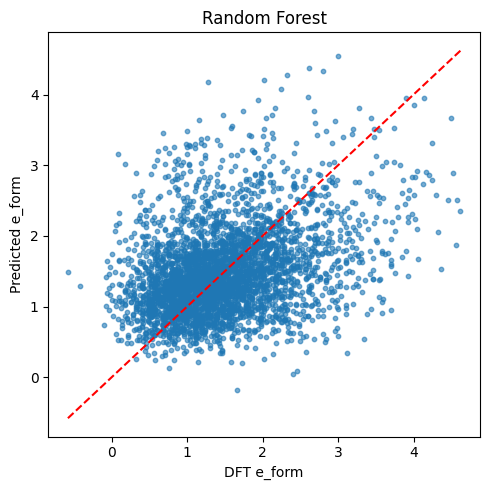

In [ ]:
# Optional second model: Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

report("Random Forest", y_test, y_pred_rf)
parity_plot(y_test, y_pred_rf, "Random Forest")

In [ ]:
# Deployment demo: screen new candidate compounds
candidate_formulas = [
    "CsPbBr3",
    "CsPbI3",
    "RbPbBr3",
    "KSnI3",
    "CsSnI3",
    "BaTiO3",
]

cand_df = pd.DataFrame({formula_col: candidate_formulas})

cand_df = str_to_comp.featurize_dataframe(cand_df, col_id=formula_col)
cand_df = ep.featurize_dataframe(cand_df, col_id="composition")

for col in feature_cols:
    if col not in cand_df.columns:
        cand_df[col] = 0.0

X_cand = cand_df[feature_cols].values.astype(np.float32)

StrToComposition:   0%|          | 0/6 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# Choose model to deploy
best_model = lin
# best_model = rf   # use this instead if RF performs better

y_cand_pred = best_model.predict(X_cand)

screen_df = pd.DataFrame({
    "formula": candidate_formulas,
    "pred_e_form": y_cand_pred
}).sort_values("pred_e_form")

screen_df

,formula,pred_e_form
4,CsSnI3,-1.834843
1,CsPbI3,-1.689797
2,RbPbBr3,-0.431508
3,KSnI3,-0.346366
0,CsPbBr3,-0.269376
5,BaTiO3,1.065645
